# Sea ice changes in concentration, thickness and volume under the SSP 2-4.5

The purpose of this notebook is to demonstrate how to compute Antarctic Sea Ice Volume and study the trend in Sea Ice Concentration and Thickness under the scenario 2-4.5.

The demo is organised to show:

Step 1: The steps to compute Sea Ice Volume using cdo and concentration and thickness as inputs.

Step 2: Gif to illustrate the Sea Ice retreat in September while defining a reference Sea Ice edge (2015)

Step 3: Compute trend of Sea Ice Concentration

In [17]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.path as mpath
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from IPython.display import Image, display
import cmocean
import os
import imageio.v2 as imageio
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import matplotlib.lines as mlines

from cdo import Cdo
cdo = Cdo()

from seaice.compute_siv_sh import compute_siv_sh
from seaice.compute_trend import compute_trend

### Define paths

In [7]:
data_dir = os.path.join("..", "data")
outputs_dir = os.path.join("..", "outputs")
results_dir = os.path.join("..", "results")

### Generate new nc files for concentration, thickness and volume for the Southern Hemisphere

In [8]:
siconc_file = os.path.join(data_dir, "siconc_ssp245_sept_subset.nc")
sithick_file = os.path.join(data_dir, "sithick_ssp245_sept_subset.nc")
compute_siv_sh(siconc_file, sithick_file, os.path.join(outputs_dir, "245"))

Sea ice volume saved to ../outputs/245_siv_sh1.nc


### Open nc files

In [9]:
# Ice volume
siv_sh_245 = xr.open_dataset(os.path.join(outputs_dir,"245_siv_sh1.nc"))

# Ice concentration
siconc_sh_245 = xr.open_dataset(os.path.join(outputs_dir,"245_siconc_sh.nc"))

# Ice thickness
sithick_sh_245 = xr.open_dataset(os.path.join(outputs_dir,"245_sithick_sh.nc"))

/Applications/anaconda3/envs/cdo_2025/lib/python3.1/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.dylib'.
dlopen(libgmt.dylib, 6): image not found
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


### Define a reference state in September 2015

In [10]:
ds_siconc_ref = siconc_sh_245.sel(time=(siconc_sh_245.time.dt.month == 9) & (siconc_sh_245.time.dt.year == 2015)) # Reference for edge contour, Sept 2015
if ds_siconc_ref is not None:
    siconc_ref = ds_siconc_ref.isel(time=0).siconc

### Generate GIF

In [11]:
### Sea ice concentration ####

ds_siconc_09 = siconc_sh_245.sel(time=siconc_sh_245.time.dt.month == 9)  # Select September data

# Get coordinate info
lats = ds_siconc_09.lat.data
lons = ds_siconc_09.lon.data

# Group by year and average
sic_yearly = ds_siconc_09.groupby("time.year").mean("time")

# Set plot settings
extent = [-180, 180, -90, -50]
data_crs = ccrs.PlateCarree()

# Create output directory
gif_dir = os.path.join(results_dir,"gif_frames_2.45")
os.makedirs(gif_dir, exist_ok=True)

# Generate individual frames
frame_paths = []
for i, year in enumerate(sic_yearly.year.values):
    sea_ice = sic_yearly.siconc.sel(year=year)

    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

    # Round boundary for polar projection
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_facecolor("darkgrey")
    ax.set_extent(extent, crs=data_crs)

    # Get values
    sic_max = np.nanmax(sea_ice)
    sic_min = np.nanmin(sea_ice)

    im = ax.pcolormesh(lons, lats, sea_ice.values, transform=data_crs, cmap= cmocean.cm.dense_r, vmin=0, vmax=100)
    
    # Add sea ice edge contour at 15%
    edge_contour = ax.contour(lons, lats, sea_ice.values, levels=[15], colors='red',
                            linewidths=1, transform=data_crs)
    
    # Add sea ice edge contour at 15% from 2015 reference

    edge_contour = ax.contour(lons, lats, siconc_ref.values, levels=[15], colors='white',
                            linewidths=1, transform=data_crs)

    # Title and colorbar
    timestamp = str(year)
    plt.title(f"{timestamp}", pad = 10)
    cbar = plt.colorbar(im, orientation='horizontal', pad=0.05, shrink=0.9, aspect=30, ticks=np.arange(0, 101, 20))
    cbar.set_label("Sea-ice concentration [%]")

    # Save frame
    frame_path = os.path.join(gif_dir, f"frame_{i:03d}.png")
    plt.savefig(frame_path, dpi=100, bbox_inches='tight')
    frame_paths.append(frame_path)
    plt.close()

# Create GIF
gif_path = os.path.join(results_dir,"sea_ice_animation_2.45.gif")
with imageio.get_writer(gif_path, mode='I', duration=0.75) as writer:
    for frame_path in frame_paths:
        image = imageio.imread(frame_path)
        writer.append_data(image)

print(f"GIF saved to {gif_path}")

GIF saved to ../results/sea_ice_animation_2.45.gif


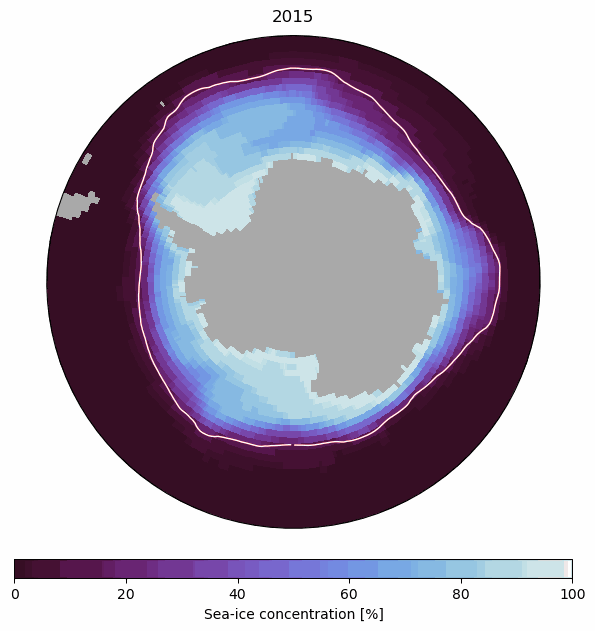

In [12]:
gif_path = os.path.join(results_dir,"sea_ice_animation_2.45.gif")
display(Image(filename=gif_path))

### Display sea ice thickness of September 2015

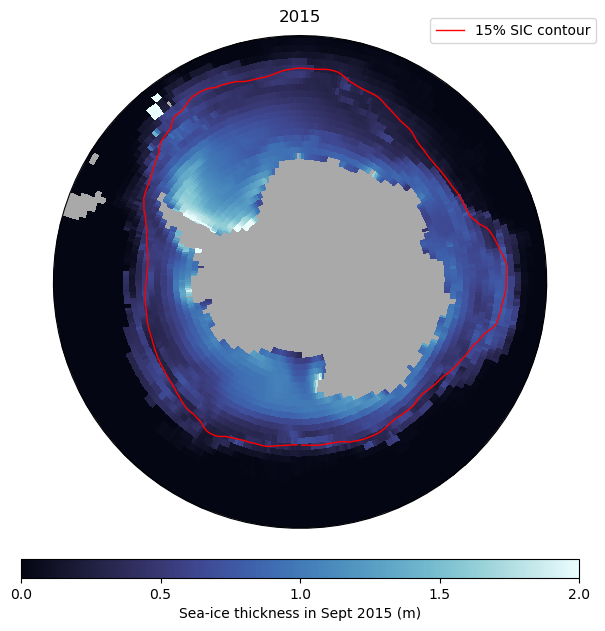

In [13]:
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
# Round boundary for polar projection
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes) 
ax.set_facecolor("darkgrey")
ax.set_extent(extent, crs=data_crs)
# Get values
ds_sithick_2015_09 = sithick_sh_245.sel(time=(sithick_sh_245.time.dt.month == 9) & (sithick_sh_245.time.dt.year == 2015))
sea_ice = ds_sithick_2015_09.sithick.isel(time=0)
sic_max = np.nanmax(sea_ice)
sic_min = np.nanmin(sea_ice)
im = ax.pcolormesh(lons, lats, sea_ice.values, transform=data_crs, cmap= cmocean.cm.ice, vmin=0, vmax=2)
# Add sea ice edge contour at 15%
edge_contour = ax.contour(lons, lats, siconc_ref.values, levels=[15], colors='red',
                            linewidths=1, transform=data_crs)

# Title and colorbar
timestamp = "2015"
plt.title(f"{timestamp}", pad = 10)
cbar = plt.colorbar(im, orientation='horizontal', pad=0.05, shrink=0.9, aspect=30, ticks=np.arange(0, 2.1, 0.5))
cbar.set_label("Sea-ice thickness in Sept 2015 (m)")

# Legend    
legend_line = mlines.Line2D([], [], color='red', linewidth=1, label='15% SIC contour')
plt.legend(handles=[legend_line], loc='upper left', bbox_to_anchor=(0.75, 1.05))

# Saving
plt.savefig(os.path.join(results_dir,"sea_ice_thickness_2015_2.45.png"), dpi=300, bbox_inches='tight')
plt.show()

### Trend of Sea Ice variables

In [14]:
trend = compute_trend(siconc_sh_245, 9, variable='siconc')
trend_v = compute_trend(siv_sh_245, 9, variable='SIV_SH')

/var/folders/v2/v2110zf17h7cbdr8jm1pjkn80000gn/T/ipykernel_4785/3401781392.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_full = plt.cm.get_cmap('bwr')


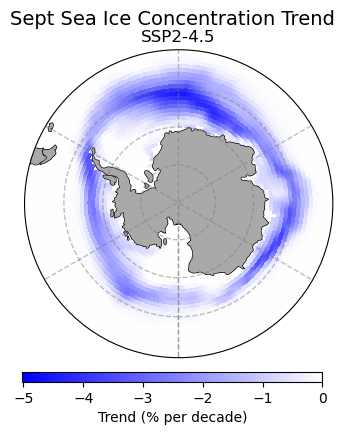

In [16]:
fig = plt.figure(figsize=(5, 4))

# Colormap — only keep the blue half of bwr (for negative trends)
cmap_full = plt.cm.get_cmap('bwr')
cmap_truncated = LinearSegmentedColormap.from_list(
    'bwr_truncated',
    cmap_full(np.linspace(0, 0.5, 256))
)
vmin, vmax = trend.min().item(), trend.max().item()

# Get lat/lon
lat = trend['lat'].values
lon = trend['lon'].values
trend_vals = trend.values

ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# Round boundary
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

ax.add_feature(cfeature.LAND, facecolor='darkgrey', zorder=2)

# Plot trend — removed TwoSlopeNorm since you're using vmin/vmax directly
im = ax.pcolormesh(lon, lat, trend_vals * 10,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap_truncated,
                   vmin=vmin*10-0.5, vmax=0
                   )

# Map details
ax.coastlines()
ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax.set_title("SSP2-4.5", fontsize=12)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.ylocator = mticker.FixedLocator(np.arange(-90, -50, 10))

# Colorbar
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Trend (% per decade)')

fig.suptitle('Sept Sea Ice Concentration Trend', fontsize=14, y=0.98)
fig.savefig(os.path.join(results_dir,"sea_ice_concentration_trend_2.45.png"), dpi=300, bbox_inches='tight')
plt.show()